# 编程实践：量子模拟器

In [1]:
# Numpy 是一个功能强大的Python库，主要用于对多维数组执行计算。
# Simulator 是模拟器，可以模拟量子计算机的计算过程。
import numpy as np                          # 导入numpy库并简写为np
from mindquantum.simulator import Simulator # 导入模拟器

# Simulator 中维护着一个量子态，初始为|0⟩态。
sim = Simulator('mqvector', 1)  # 实例化'mqvector'模拟器,量子比特数为1
print(sim)                      # 打印模拟器信息

mqvector simulator with 1 qubit (little endian), dtype: mindquantum.complex128.
Current quantum state:
1¦0⟩


In [2]:
# 通过 set_qs() 可以将量子态设置为任意的非零列向量，接口会自动进行归一化。
plus_state = np.array([1, 1])   # 构造¦+⟩态
sim.set_qs(plus_state)          # 将量子态设置为¦+⟩态

quantum_state = sim.get_qs()    # 获取当前量子态
ket = sim.get_qs(ket=True)      # 获取当前量子态的狄拉克符号形式
print('quantum state:', quantum_state)
print('ket:\n', ket)

quantum state: [0.70710678+0.j 0.70710678+0.j]
ket:
 √2/2¦0⟩
√2/2¦1⟩


# 编程实践：量子门

In [3]:
from mindquantum.core.gates import X, Y, H      # 导入量子门
from mindquantum.simulator import Simulator     # 导入模拟器

# 每个量子门都有 matrix() 方法，可以获取该量子门的矩阵形式。
print('Gate name:', X)
gateX = X.matrix()
print(gateX)

Gate name: X
[[0 1]
 [1 0]]


In [4]:
print('Gate name:', Y)
gateY = Y.matrix()
print(gateY)

Gate name: Y
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]


In [5]:
print('Gate name:', H)
gateH = H.matrix()
print(gateH)

Gate name: H
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In [6]:
# 调用 Simulator 的 apply_gate() 接口可以将量子门作用在量子比特上，使量子态发生演化。
# on() 方法可以指定量子门作用在哪个量子比特上（目标比特），受哪些比特控制（控制比特）。
sim = Simulator('mqvector', 1)          # 实例化一个模拟器
sim.apply_gate(H.on(0))                 # 将H门作用于q0
print(sim)

mqvector simulator with 1 qubit (little endian), dtype: mindquantum.complex128.
Current quantum state:
√2/2¦0⟩
√2/2¦1⟩


# 编程实践：量子线路

In [7]:
from mindquantum.core.gates import X, Y, H   # 导入量子门X, Y, H
from mindquantum.core.circuit import Circuit # 导入Circuit模块，用于搭建量子线路
from mindquantum.simulator import Simulator  # 导入模拟器

# 通过“+=”的方式可以轻松地将量子门添加到量子线路中。
circ = Circuit() 			# 实例化一个量子线路
circ += H.on(0)  			# 在线路上的第0个比特添加一个H门
circ += Y.on(0) 			# 在线路上的第0个比特添加一个Y门
circ += X.on(1) 			# 在线路上的第1个比特添加一个X门

print(circ)

      ┏━━━┓ ┏━━━┓   
q0: ──┨ H ┠─┨ Y ┠───
      ┗━━━┛ ┗━━━┛   
      ┏━━━┓         
q1: ──┨╺╋╸┠─────────
      ┗━━━┛         


In [8]:
mat = circ.matrix() 		# 获取线路对应的矩阵
print('circuit matrix:\n', mat)

circuit matrix:
 [[0.+0.j         0.+0.j         0.-0.70710678j 0.+0.70710678j]
 [0.+0.j         0.+0.j         0.+0.70710678j 0.+0.70710678j]
 [0.-0.70710678j 0.+0.70710678j 0.+0.j         0.+0.j        ]
 [0.+0.70710678j 0.+0.70710678j 0.+0.j         0.+0.j        ]]


In [9]:
# 调用 Simulator 的 apply_circuit() 接口可以将量子线路作用在量子比特上，使量子态发生演化。
sim = Simulator('mqvector', 2)  	# 实例化一个两比特的模拟器
sim.apply_circuit(circ)          	# 作用量子线路
print(sim)

mqvector simulator with 2 qubits (little endian), dtype: mindquantum.complex128.
Current quantum state:
-√2/2j¦10⟩
√2/2j¦11⟩


# 编程实践：量子测量

In [10]:
from mindquantum.core.gates import Measure, H, X, Y # 导入量子门X, Y, H和量子测量Measure
from mindquantum.core.circuit import Circuit        # 导入Circuit模块，用于搭建量子线路
from mindquantum.simulator import Simulator         # 导入模拟器

circ = Circuit()                    # 实例化一个量子线路
circ += H.on(0)                     # 在线路上的第0个比特添加一个H门
circ += Y.on(0)                     # 在线路上的第0个比特添加一个Y门
circ += X.on(1)                     # 在线路上的第1个比特添加一个X门

# Measure 与量子门类似，可以用“+=”的方式添加到量子线路中，用 on() 方法指定目标比特。
circ += Measure().on(0)             # 在线路上的第0个比特添加一个测量
circ += Measure().on(1)             # 在线路上的第1个比特添加一个测量

print(circ)

      ┏━━━┓ ┏━━━┓ ┍━━━━━━┑   
q0: ──┨ H ┠─┨ Y ┠─┤ M q0 ├───
      ┗━━━┛ ┗━━━┛ ┕━━━━━━┙   
      ┏━━━┓ ┍━━━━━━┑         
q1: ──┨╺╋╸┠─┤ M q1 ├─────────
      ┗━━━┛ ┕━━━━━━┙         


In [11]:
# 调用 Simulator 的 sampling() 接口可以对某一线路的演化结果进行多次采样，获得量子测量的统计结果。
# 这一过程与真实量子计算机的运行方式相似。
sim = Simulator('mqvector', 2)              # 实例化一个两比特的模拟器
result = sim.sampling(circ, shots=1000) 	# 对该线路的演化结果进行1000次采样
print(result)

shots: 1000
Keys: q1 q0│0.00   0.126       0.252       0.378       0.504        0.63
───────────┼───────────┴───────────┴───────────┴───────────┴───────────┴
         10│▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
           │
         11│▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
           │
{'10': 504, '11': 496}


# 作业1

1. 请搭建出如下线路。
2. 请打印线路运行后的量子态。
3. 请在线路末尾添加测量，并采样线路运行结果10000次，观察得到的分布。


<img src="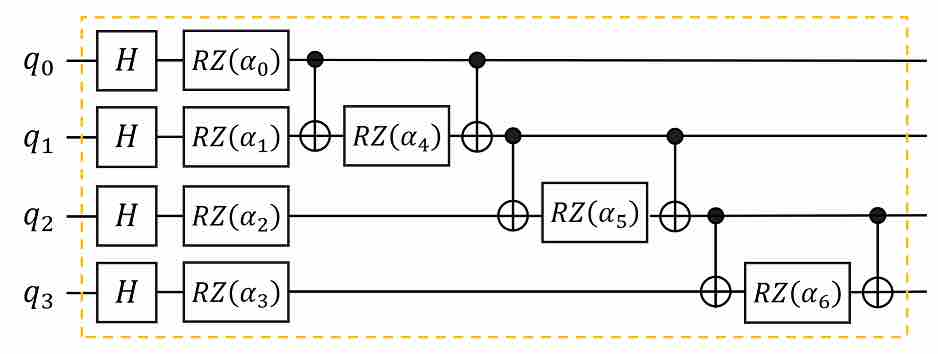
" width="400"/>

其中 $\alpha_0, \alpha_1, ⋯, \alpha_6$ 可以是任意值。

**预期结果：** 对于随意的 $\alpha_0, \alpha_1, ⋯, \alpha_6$ ，运行线路后的量子态应该难以发现规律，但添加测量后采样10000次的统计结果却是近似均匀分布。

**解释：** 该线路是IQP编码线路，可以将经典信息编码到量子态上。当选取RZ⻔时，RZ⻔只会改变相位信息，而不会改变振幅信息，即 $\alpha_0, \alpha_1, ⋯, \alpha_6$ 的信息将被编码至相位上。量子态中包含了振幅和相位的完整信息，因此难以发现规律；而采样得到的分布只与量子态的振幅有关，因此呈现均匀分布。

**请在标记为`#TODO`的位置完成代码编写，并将包裹代码的多行注释符`""" """`删除。每个TODO位置需要根据注释说明实现相应功能。**

In [12]:
from mindquantum.core.gates import H, X, RZ
from mindquantum.core.circuit import Circuit
from mindquantum.simulator import Simulator


# TODO: 请根据图中所示构建量子线路
circ = Circuit()
# 在这里添加量子门...
circ += H.on(0)
circ += H.on(1)
circ += H.on(2)
circ += H.on(3) 
circ += RZ('a0').on(0)
circ += RZ('a1').on(1)
circ += RZ('a2').on(2)
circ += RZ('a3').on(3)
circ += X.on(1,0)
circ += RZ('a4').on(1)
circ += X.on(1,0)
circ += X.on(2,1)
circ += RZ('a5').on(2)
circ += X.on(2,1)
circ += X.on(3,2)
circ += RZ('a6').on(3)
circ += X.on(3,2)
circ.svg()


# TODO: 使用模拟器运行线路，打印运行后的量子态
sim = Simulator('mqvector', circ.n_qubits)
# 在这里补充代码...
sim.apply_circuit(circ,pr={'a0': np.random.rand(),'a1': np.random.rand(), 'a2': np.random.rand(), 'a3': np.random.rand(), 'a4': np.random.rand(), 'a5': np.random.rand(),'a6': np.random.rand()})
print(sim.get_qs(True))  #查看模拟器状态,以numpy.ndarray形式返回结果


# TODO: 使用模拟器采样线路结果10000次
sim = Simulator('mqvector', circ.n_qubits)
circ += Measure().on(0)
circ += Measure().on(1)
circ += Measure().on(2)
circ += Measure().on(3)
circ.svg()
res = sim.sampling(circ,pr={'a0': np.random.rand(),'a1': np.random.rand(), 'a2': np.random.rand(), 'a3': np.random.rand(), 'a4': np.random.rand(), 'a5': np.random.rand(),'a6': np.random.rand()}, shots=10000)  # 对上面定义的线路采样10000次
res.svg()
print(res)



(-0.01635635-0.24946437j)¦0000⟩
(0.21943792-0.11977897j)¦0001⟩
(0.23606123-0.08231097j)¦0010⟩
(0.16978485-0.18350233j)¦0011⟩
(0.20086961-0.14883346j)¦0100⟩
(0.21952253+0.11962381j)¦0101⟩
(0.23704245+0.07944103j)¦0110⟩
(0.24659088-0.04114535j)¦0111⟩
(0.17651378-0.17703922j)¦1000⟩
(0.23486572+0.08566268j)¦1001⟩
(0.21771078+0.12289027j)¦1010⟩
(0.24992077+0.00629368j)¦1011⟩
(0.24715155+0.03763126j)¦1100⟩
(0.06982756+0.24005023j)¦1101⟩
(0.11068349+0.22416325j)¦1110⟩
(0.20296773+0.14595924j)¦1111⟩
shots: 10000
Keys: q3 q2 q1 q0│0.00   0.017       0.033        0.05       0.067       0.083
─────────────────┼───────────┴───────────┴───────────┴───────────┴───────────┴
             0000│▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
                 │
             0001│▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
                 │
             0010│▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
                 │
             0011│▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒
                 │
 